# Assignment 04 — Novel CNN Architectures for Lightweight Deep Learning

## Title
**Implementation of Efficient CNN Models: MobileNetV2, DenseNet121, and EfficientNetB0**

## Objective
Implement modern CNN architectures and evaluate their suitability for **resource-constrained systems**.

## Dataset
We use **CIFAR-10** (10 classes). (You can switch to MNIST/Fashion-MNIST later if required.)

## Deliverables (inside this notebook)
- ✅ Source code (TensorFlow/Keras)
- ✅ Comparison table (accuracy, params, size, inference speed, memory)
- ✅ Performance graphs
- ✅ CPU-only test for one model
- ✅ Final recommendation report
- ✅ All artifacts saved to Google Drive (`OUTPUT_DIR`)

---

### Colab runtime
`Runtime → Change runtime type → GPU (T4)`


In [1]:
# =============================
# 1) Setup
# =============================
import os
import time
import json
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1.1) Google Drive (Save all outputs)
This mounts Google Drive and creates an output folder for **models, plots, tables, and reports**.


In [2]:
# Mount Drive (Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print('Not running in Colab (Drive mount skipped):', e)

DRIVE_ROOT = '/content/drive/MyDrive'
PROJECT_DIR = f"{DRIVE_ROOT}/COMP-443/Assignment_04_Efficient_CNNs"
LOCAL_DIR = '/content/assignment04_outputs'

OUTPUT_DIR = PROJECT_DIR if IN_COLAB else LOCAL_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('OUTPUT_DIR =', OUTPUT_DIR)


Mounted at /content/drive
OUTPUT_DIR = /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs


## 2) Dataset: CIFAR-10
All three backbones will use the **same input size** and **same training settings** for a fair comparison.

- Input size: **224×224** (common for MobileNetV2, DenseNet121, EfficientNetB0)
- Augmentation: flip + small contrast
- Training: head training + optional light fine-tune


In [3]:
# =============================
# 2) Load CIFAR-10
# =============================
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze().astype('int32')
y_test  = y_test.squeeze().astype('int32')

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]
num_classes = len(class_names)
print('Train:', x_train.shape, y_train.shape)
print('Test :', x_test.shape, y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


In [4]:
# Train/val split

def make_splits(x, y, val_fraction=0.1):
    n = x.shape[0]
    n_val = int(n * val_fraction)
    idx = np.arange(n)
    rng = np.random.default_rng(SEED)
    rng.shuffle(idx)
    val_idx = idx[:n_val]
    tr_idx  = idx[n_val:]
    return (x[tr_idx], y[tr_idx]), (x[val_idx], y[val_idx])

(x_tr, y_tr), (x_val, y_val) = make_splits(x_train, y_train, 0.1)
print('Train split:', x_tr.shape, y_tr.shape)
print('Val split  :', x_val.shape, y_val.shape)


Train split: (45000, 32, 32, 3) (45000,)
Val split  : (5000, 32, 32, 3) (5000,)


In [5]:
# =============================
# 3) tf.data pipeline
# =============================
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)

augment = keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomContrast(0.1, seed=SEED),
], name='augmentation')

# Preprocess functions (model-specific)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess


def make_dataset(x, y, batch_size, image_size, preprocess_fn, training):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10_000, seed=SEED, reshuffle_each_iteration=True)

    def _map(img, label):
        img = tf.cast(img, tf.float32)
        if training:
            img = augment(img)
        img = tf.image.resize(img, image_size, method='bilinear')
        img = preprocess_fn(img)
        return img, tf.one_hot(label, num_classes)

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    # Cache helps performance in Colab RAM
    ds = ds.cache()
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


def make_all_datasets(preprocess_fn):
    train_ds = make_dataset(x_tr, y_tr, BATCH_SIZE, IMAGE_SIZE, preprocess_fn, training=True)
    val_ds   = make_dataset(x_val, y_val, BATCH_SIZE, IMAGE_SIZE, preprocess_fn, training=False)
    test_ds  = make_dataset(x_test, y_test, BATCH_SIZE, IMAGE_SIZE, preprocess_fn, training=False)
    return train_ds, val_ds, test_ds

# quick sanity check
train_ds_tmp, _, _ = make_all_datasets(mobilenet_preprocess)
xb, yb = next(iter(train_ds_tmp))
print('Batch:', xb.shape, yb.shape)


Batch: (64, 224, 224, 3) (64, 10)


## 4) Model builders (Transfer Learning)
We use ImageNet-pretrained backbones with `include_top=False` and replace the classifier for 10 classes.


In [6]:
# =============================
# 4) Model builders
# =============================
from tensorflow.keras.applications import MobileNetV2, DenseNet121, EfficientNetB0


def build_transfer_model(backbone_name, num_classes):
    if backbone_name == 'MobileNetV2':
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3), pooling='avg')
    elif backbone_name == 'DenseNet121':
        base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3), pooling='avg')
    elif backbone_name == 'EfficientNetB0':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3), pooling='avg')
    else:
        raise ValueError('Unknown backbone: ' + backbone_name)

    base.trainable = False

    inputs = keras.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=f'{backbone_name}_transfer')
    return model


def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )


def fit_with_timing(model, train_ds, val_ds, epochs, callbacks=None):
    t0 = time.perf_counter()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks or [], verbose=1)
    t1 = time.perf_counter()
    return hist, (t1 - t0)


## 5) Train all models with the same settings
We train in two stages:
1) Train classifier head (backbone frozen)
2) Light fine-tuning (unfreeze last N layers) with lower LR

You can reduce epochs if you want faster execution.


In [7]:
# =============================
# 5) Training config
# =============================
EPOCHS_HEAD = 8
EPOCHS_FT = 7
DO_FINE_TUNE = True

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
]


In [8]:
# Helper: fine-tune last N layers

def fine_tune(model, backbone_substring, unfreeze_last_n):
    # Locate backbone
    backbone = None
    for layer in model.layers:
        if backbone_substring.lower() in layer.name.lower():
            backbone = layer
            break
    if backbone is None:
        # fallback: first layer that is a keras.Model
        for layer in model.layers:
            if isinstance(layer, keras.Model):
                backbone = layer
                break

    backbone.trainable = True
    layers_list = backbone.layers
    for l in layers_list[:-unfreeze_last_n]:
        l.trainable = False

    return backbone


In [9]:
# =============================
# 5.1) MobileNetV2
# =============================
train_mnet, val_mnet, test_mnet = make_all_datasets(mobilenet_preprocess)

mobilenet_model = build_transfer_model('MobileNetV2', num_classes)
compile_model(mobilenet_model, lr=1e-3)

mnet_hist_head, mnet_time_head = fit_with_timing(mobilenet_model, train_mnet, val_mnet, EPOCHS_HEAD, callbacks)

mnet_time_ft = 0.0
mnet_hist_ft = None
if DO_FINE_TUNE:
    fine_tune(mobilenet_model, 'mobilenet', unfreeze_last_n=40)
    compile_model(mobilenet_model, lr=1e-4)
    mnet_hist_ft, mnet_time_ft = fit_with_timing(mobilenet_model, train_mnet, val_mnet, EPOCHS_FT, callbacks)

print('MobileNetV2 time (min):', (mnet_time_head+mnet_time_ft)/60)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 67ms/step - accuracy: 0.7515 - loss: 0.7254 - val_accuracy: 0.8352 - val_loss: 0.4792 - learning_rate: 0.0010
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8210 - loss: 0.5242 - val_accuracy: 0.8508 - val_loss: 0.4428 - learning_rate: 0.0010
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8275 - loss: 0.4988 - val_accuracy: 0.8544 - val_loss: 0.4376 - learning_rate: 0.0010
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8302 - loss: 0.4864 - val_accuracy: 0.8502 - val_loss: 0.4349 - learning_rate: 0.0010
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8345 - loss: 0.4809 - val_accuracy: 0.8546 - val_loss: 0.4260 - learning_rate: 0.0010
Epoch 6/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8336 - loss: 0.4837 - val_accuracy: 0.8550 - val_loss: 0.4284 - learning_rate: 0.0010
Epoch 7/8
703/704 ━━━━━━━━━━━━━━━

In [10]:
# =============================
# 5.2) DenseNet121
# =============================
train_dnet, val_dnet, test_dnet = make_all_datasets(densenet_preprocess)

densenet_model = build_transfer_model('DenseNet121', num_classes)
compile_model(densenet_model, lr=1e-3)

dnet_hist_head, dnet_time_head = fit_with_timing(densenet_model, train_dnet, val_dnet, EPOCHS_HEAD, callbacks)

dnet_time_ft = 0.0
dnet_hist_ft = None
if DO_FINE_TUNE:
    fine_tune(densenet_model, 'densenet', unfreeze_last_n=60)
    compile_model(densenet_model, lr=1e-4)
    dnet_hist_ft, dnet_time_ft = fit_with_timing(densenet_model, train_dnet, val_dnet, EPOCHS_FT, callbacks)

print('DenseNet121 time (min):', (dnet_time_head+dnet_time_ft)/60)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 102ms/step - accuracy: 0.7691 - loss: 0.6848 - val_accuracy: 0.8736 - val_loss: 0.3845 - learning_rate: 0.0010
Epoch 2/8
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8433 - loss: 0.4554
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8483 - loss: 0.4416 - val_accuracy: 0.8820 - val_loss: 0.3509 - learning_rate: 0.0010
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8607 - loss: 0.4080 - val_accuracy: 0.8884 - val_loss: 0.3296 - learning_rate: 5.0000e-04
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8592 - loss: 0.4054 - val_accuracy: 0.8888 - val_loss: 0.3262 - learning_rate: 5.0000e-04
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8610 - loss: 0.4018 - val_accuracy: 0.8912 - val_loss: 0.3239 - learning_rate: 5.0000e-04
Epoch 6/8
704/704 

In [11]:
# =============================
# 5.3) EfficientNetB0
# =============================
train_enet, val_enet, test_enet = make_all_datasets(effnet_preprocess)

effnet_model = build_transfer_model('EfficientNetB0', num_classes)
compile_model(effnet_model, lr=1e-3)

enet_hist_head, enet_time_head = fit_with_timing(effnet_model, train_enet, val_enet, EPOCHS_HEAD, callbacks)

enet_time_ft = 0.0
enet_hist_ft = None
if DO_FINE_TUNE:
    fine_tune(effnet_model, 'efficientnet', unfreeze_last_n=50)
    compile_model(effnet_model, lr=1e-4)
    enet_hist_ft, enet_time_ft = fit_with_timing(effnet_model, train_enet, val_enet, EPOCHS_FT, callbacks)

print('EfficientNetB0 time (min):', (enet_time_head+enet_time_ft)/60)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.8207 - loss: 0.5580 - val_accuracy: 0.8888 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 2/8
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8672 - loss: 0.3890
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8730 - loss: 0.3758 - val_accuracy: 0.8972 - val_loss: 0.2967 - learning_rate: 0.0010
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8815 - loss: 0.3471 - val_accuracy: 0.9014 - val_loss: 0.2861 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - accuracy: 0.8908 - loss: 0.3256 - val_accuracy: 0.9394 - val_loss: 0.1810 - learning_rate: 1.0000e-04
Epoch 2/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9360 - loss: 0.1897 - val_a

## 6) Evaluation: Accuracy, Parameters, Model Size
We evaluate test accuracy/loss and save each model to Drive to measure file size.


In [12]:
# =============================
# 6) Evaluate & save
# =============================

def eval_and_save(model, test_ds, name):
    loss, acc = model.evaluate(test_ds, verbose=0)

    model_path = os.path.join(OUTPUT_DIR, f'{name}.keras')
    model.save(model_path, include_optimizer=False)
    size_mb = os.path.getsize(model_path) / (1024**2)

    return {
        'model': name,
        'test_accuracy': float(acc),
        'test_loss': float(loss),
        'params': int(model.count_params()),
        'model_size_mb': float(size_mb),
        'model_path': model_path,
    }

mnet_metrics = eval_and_save(mobilenet_model, test_mnet, 'mobilenetv2_cifar10_transfer')
dnet_metrics = eval_and_save(densenet_model, test_dnet, 'densenet121_cifar10_transfer')
enet_metrics = eval_and_save(effnet_model, test_enet, 'efficientnetb0_cifar10_transfer')

mnet_metrics, dnet_metrics, enet_metrics


({'model': 'mobilenetv2_cifar10_transfer',
  'test_accuracy': 0.9002000093460083,
  'test_loss': 0.33982688188552856,
  'params': 2270794,
  'model_size_mb': 22.175517082214355,
  'model_path': '/content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/mobilenetv2_cifar10_transfer.keras'},
 {'model': 'densenet121_cifar10_transfer',
  'test_accuracy': 0.9261000156402588,
  'test_loss': 0.22459569573402405,
  'params': 7047754,
  'model_size_mb': 37.7080135345459,
  'model_path': '/content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/densenet121_cifar10_transfer.keras'},
 {'model': 'efficientnetb0_cifar10_transfer',
  'test_accuracy': 0.9488000273704529,
  'test_loss': 0.1618230938911438,
  'params': 4062381,
  'model_size_mb': 34.023091316223145,
  'model_path': '/content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/efficientnetb0_cifar10_transfer.keras'})

## 7) Inference Speed Benchmark (GPU + CPU)
We benchmark **average inference time per batch**.

Notes:
- We run a warmup first.
- We measure on GPU if available.
- We also measure CPU inference for **one model** as required.


In [13]:
# =============================
# 7) Speed + memory benchmark
# =============================

def benchmark_inference(model, sample_ds, device=None, steps=50, warmup=10):
    it = iter(sample_ds)

    # compile predict to graph for stable timing
    @tf.function
    def _predict(x):
        return model(x, training=False)

    # warmup
    for _ in range(warmup):
        x, _ = next(it)
        if device:
            with tf.device(device):
                _ = _predict(x)
        else:
            _ = _predict(x)

    # timed
    times = []
    for _ in range(steps):
        x, _ = next(it)
        t0 = time.perf_counter()
        if device:
            with tf.device(device):
                _ = _predict(x)
        else:
            _ = _predict(x)
        # ensure sync
        _ = tf.reduce_sum(_)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    return float(np.mean(times)), float(np.std(times))


def get_rss_mb():
    try:
        import psutil
        import os as _os
        p = psutil.Process(_os.getpid())
        return p.memory_info().rss / (1024**2)
    except Exception:
        return None

# GPU benchmark (if available)
gpu_device = '/GPU:0' if tf.config.list_physical_devices('GPU') else None

rss_before = get_rss_mb()

mnet_gpu_mean, mnet_gpu_std = benchmark_inference(mobilenet_model, test_mnet, device=gpu_device)
dnet_gpu_mean, dnet_gpu_std = benchmark_inference(densenet_model, test_dnet, device=gpu_device)
enet_gpu_mean, enet_gpu_std = benchmark_inference(effnet_model, test_enet, device=gpu_device)

rss_after = get_rss_mb()

print('GPU mean seconds/batch:')
print('MobileNetV2   ', mnet_gpu_mean)
print('DenseNet121   ', dnet_gpu_mean)
print('EfficientNetB0', enet_gpu_mean)
print('RSS before/after (MB):', rss_before, rss_after)


GPU mean seconds/batch:
MobileNetV2    0.021823429800001577
DenseNet121    0.043466563980000504
EfficientNetB0 0.029900258160000703
RSS before/after (MB): 114416.13671875 114495.9375


In [14]:
# CPU-only test (required): run MobileNetV2 on CPU
mnet_cpu_mean, mnet_cpu_std = benchmark_inference(mobilenet_model, test_mnet, device='/CPU:0')
print('MobileNetV2 CPU mean seconds/batch:', mnet_cpu_mean)


MobileNetV2 CPU mean seconds/batch: 0.2854669776199853


## 8) Training Curves + Comparison Graphs


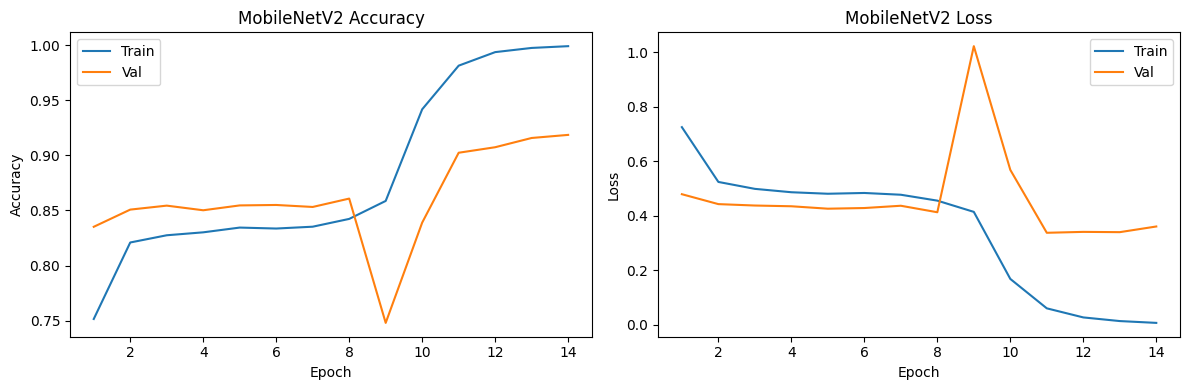

Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/mobilenetv2_curves.png


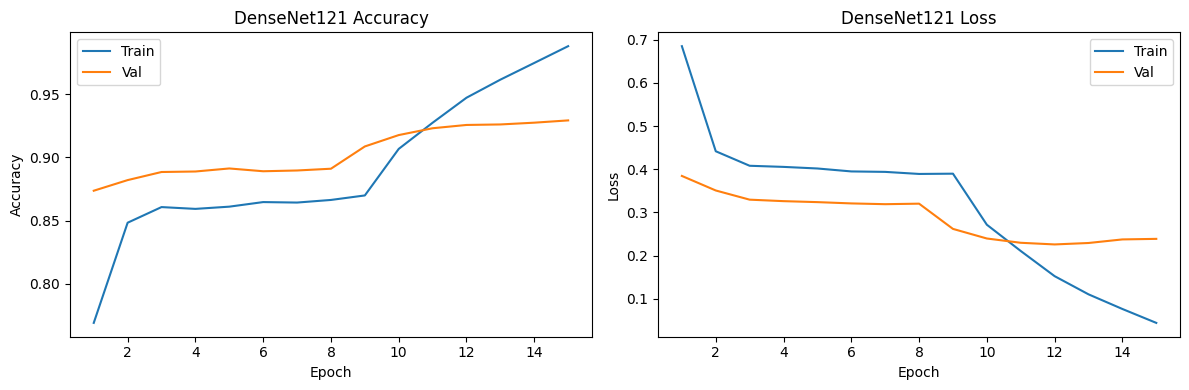

Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/densenet121_curves.png


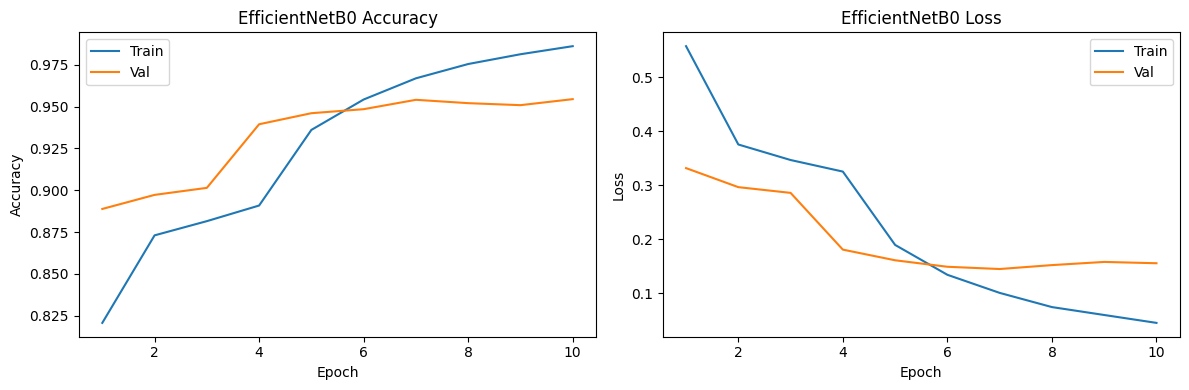

Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/efficientnetb0_curves.png


In [15]:
# =============================
# 8) Curves
# =============================

def merge_histories(h1, h2):
    if h2 is None:
        return h1.history
    merged = {k: list(h1.history.get(k, [])) + list(h2.history.get(k, [])) for k in set(h1.history) | set(h2.history)}
    return merged

mnet_hist = merge_histories(mnet_hist_head, mnet_hist_ft)
dnet_hist = merge_histories(dnet_hist_head, dnet_hist_ft)
enet_hist = merge_histories(enet_hist_head, enet_hist_ft)


def plot_curves(hist, title, fname):
    acc = hist.get('accuracy', [])
    val_acc = hist.get('val_accuracy', [])
    loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label='Train')
    plt.plot(epochs, val_acc, label='Val')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label='Train')
    plt.plot(epochs, val_loss, label='Val')
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, fname)
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved', out)

plot_curves(mnet_hist, 'MobileNetV2', 'mobilenetv2_curves.png')
plot_curves(dnet_hist, 'DenseNet121', 'densenet121_curves.png')
plot_curves(enet_hist, 'EfficientNetB0', 'efficientnetb0_curves.png')


In [16]:
# =============================
# 9) Comparison table + graphs
# =============================
import pandas as pd

results = [
    {
        **mnet_metrics,
        'train_time_min': float((mnet_time_head+mnet_time_ft)/60),
        'gpu_sec_per_batch': float(mnet_gpu_mean),
        'cpu_sec_per_batch': float(mnet_cpu_mean),
    },
    {
        **dnet_metrics,
        'train_time_min': float((dnet_time_head+dnet_time_ft)/60),
        'gpu_sec_per_batch': float(dnet_gpu_mean),
        'cpu_sec_per_batch': None,
    },
    {
        **enet_metrics,
        'train_time_min': float((enet_time_head+enet_time_ft)/60),
        'gpu_sec_per_batch': float(enet_gpu_mean),
        'cpu_sec_per_batch': None,
    },
]

df = pd.DataFrame(results)
df


,model,test_accuracy,test_loss,params,model_size_mb,model_path,train_time_min,gpu_sec_per_batch,cpu_sec_per_batch
0,mobilenetv2_cifar10_transfer,0.9002,0.339827,2270794,22.175517,/content/drive/MyDrive/COMP-443/Assignment_04_...,5.495559,0.021823,0.285467
1,densenet121_cifar10_transfer,0.9261,0.224596,7047754,37.708014,/content/drive/MyDrive/COMP-443/Assignment_04_...,9.499596,0.043467,NaN
2,efficientnetb0_cifar10_transfer,0.9488,0.161823,4062381,34.023091,/content/drive/MyDrive/COMP-443/Assignment_04_...,5.415688,0.029900,NaN


In [17]:
# Save table
csv_path = os.path.join(OUTPUT_DIR, 'comparison_table.csv')
df.to_csv(csv_path, index=False)
print('Saved', csv_path)


Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/comparison_table.csv


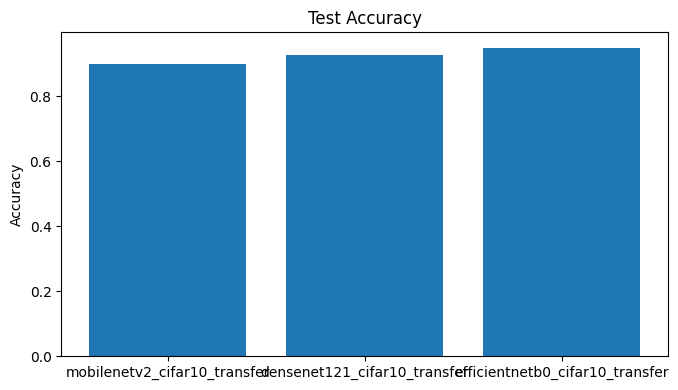

Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/bar_accuracy.png


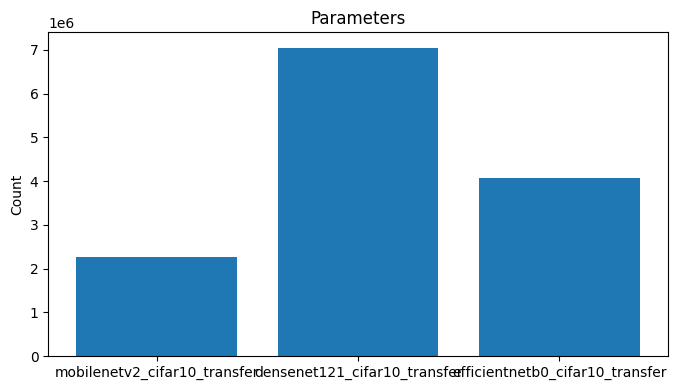

Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/bar_params.png


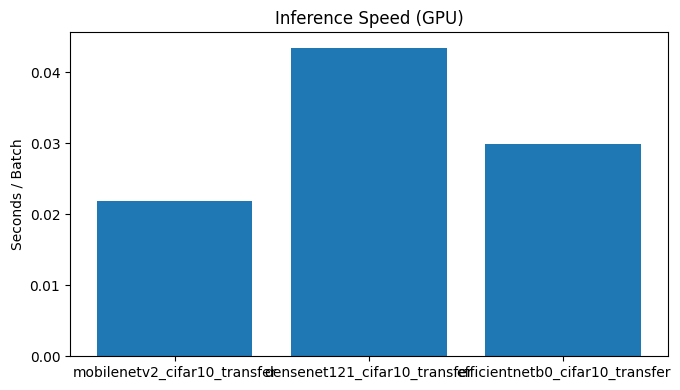

Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/bar_gpu_speed.png


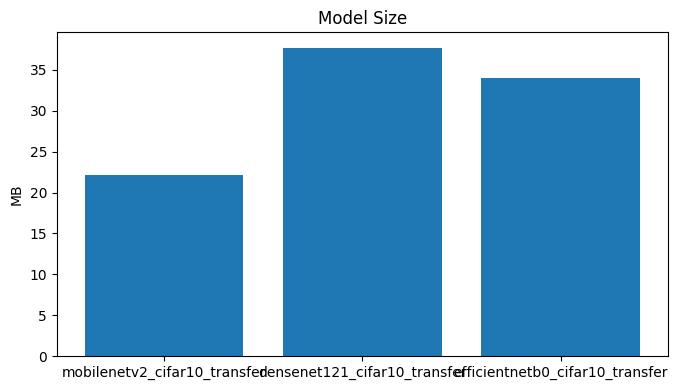

Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/bar_model_size.png


In [18]:
# Bar charts

def barplot(x, y, title, ylabel, fname):
    plt.figure(figsize=(7,4))
    plt.bar(x, y)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, fname)
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved', out)

barplot(df['model'], df['test_accuracy'], 'Test Accuracy', 'Accuracy', 'bar_accuracy.png')
barplot(df['model'], df['params'], 'Parameters', 'Count', 'bar_params.png')
barplot(df['model'], df['gpu_sec_per_batch'], 'Inference Speed (GPU)', 'Seconds / Batch', 'bar_gpu_speed.png')
barplot(df['model'], df['model_size_mb'], 'Model Size', 'MB', 'bar_model_size.png')


## 10) Final Recommendation Report (HTML + Markdown)
We generate a standalone HTML report and a Markdown report saved in `OUTPUT_DIR`.

You should edit the recommendation section based on your measured results.


In [24]:
# =============================
# 10) Export report.html + report.md
# =============================
import os
import datetime

generated_at = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

report_html = f"""<!doctype html>
  <html lang="en">
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>Assignment 04 — Efficient CNNs Report</title>
    <style>
      body {{ font-family: Arial, sans-serif; margin: 24px; line-height: 1.45; }}
      h1,h2,h3 {{ margin-bottom: 8px; }}
      .meta {{ color: #444; margin-bottom: 18px; }}
      table {{ border-collapse: collapse; width: 100%; }}
      th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
      th {{ background: #f5f5f5; }}
      figure {{ margin: 16px 0; }}
      figcaption {{ color: #555; font-size: 0.95em; margin-top: 6px; }}
      code {{ background:#f6f6f6; padding:2px 4px; }}
    </style>
  </head>
  <body>
    <h1>Assignment 04 Report — Efficient CNN Architectures</h1>
    <div class="meta">
      Generated: {generated_at}<br>
      Dataset: CIFAR-10<br>
      Models: MobileNetV2, DenseNet121, EfficientNetB0
    </div>

    <h2>Comparison Table</h2>
    {df.to_html(index=False)}

    <h2>Graphs</h2>
    <ul>
      <li>Accuracy bar: <code>bar_accuracy.png</code></li>
      <li>Params bar: <code>bar_params.png</code></li>
      <li>GPU speed bar: <code>bar_gpu_speed.png</code></li>
      <li>Model size bar: <code>bar_model_size.png</code></li>
      <li>Training curves:
        <code>mobilenetv2_curves.png</code>,
        <code>densenet121_curves.png</code>,
        <code>efficientnetb0_curves.png</code>
      </li>
    </ul>

    <h2>CPU-only test</h2>
    <p>MobileNetV2 CPU seconds/batch: <b>{mnet_cpu_mean:.6f}</b></p>

    <h2>Recommendations (template)</h2>
    <h3>Mobile phone</h3>
    <p><b>MobileNetV2</b> is typically a strong choice due to low parameter count and fast inference.</p>

    <h3>Cloud server</h3>
    <p><b>DenseNet121</b> or <b>EfficientNetB0</b> can be preferred if they achieve higher accuracy and inference cost is acceptable.</p>

    <h3>Real-time system</h3>
    <p>Prefer the model with the best speed/accuracy tradeoff (often <b>MobileNetV2</b> or <b>EfficientNetB0</b>).</p>

    <h2>Outputs</h2>
    <p>All artifacts saved to: <code>{OUTPUT_DIR}</code></p>
  </body>
  </html>
  """

html_path = os.path.join(OUTPUT_DIR, "report.html")
with open(html_path, "w", encoding="utf-8") as f:
    f.write(report_html)
print("Saved", html_path)

report_md = f"""# Assignment 04 Report — Efficient CNN Architectures

  Generated: {generated_at}

  Outputs folder: `{OUTPUT_DIR}`

  ## Models
  - MobileNetV2
  - DenseNet121
  - EfficientNetB0

  ## Key files
  - `comparison_table.csv`
  - `report.html`
  - `bar_accuracy.png`, `bar_params.png`, `bar_gpu_speed.png`, `bar_model_size.png`
  - `mobilenetv2_curves.png`, `densenet121_curves.png`, `efficientnetb0_curves.png`

  ## Recommendations (fill using your results)
  - Mobile phone: ...
  - Cloud server: ...
  - Real-time system: ...
  """

md_path = os.path.join(OUTPUT_DIR, "report.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write(report_md)
print("Saved", md_path)

Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/report.html
Saved /content/drive/MyDrive/COMP-443/Assignment_04_Efficient_CNNs/report.md


## Bonus (Optional): Deployment
If you want, we can deploy the best model with **Streamlit** or **Gradio** in a separate notebook/script.
